In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
from typing import Iterable

In [39]:
order_details = pd.read_csv('../Order_Details.csv')
orders = pd.read_csv('../Orders.csv')
categories = pd.read_csv('../Categories_ENG.csv', sep=None, engine='python', index_col=0)

In [4]:
cost = pd.read_csv('../cost.csv')

In [41]:
order_details = (order_details.merge(orders[['ORDERID','DATE_']], how='left', on='ORDERID'))

In [42]:
data = order_details.merge(categories[['ITEMCODE', 'CATEGORY1', 'CATEGORY2']], how='left', on='ITEMCODE')

In [3]:
from pathlib import Path

In [11]:

cost = pd.read_csv(
'cost.csv'
) 

In [ ]:
data.to_csv(Path(__file__).parent.parent)

In [10]:
data = pd.read_csv('full_data.csv')

In [12]:
data = data.merge(cost[['ITEMCODE', 'cost']], how='left', on='ITEMCODE')


In [46]:
data = data[data.CATEGORY1 == 'Home']

In [13]:
data =  data[data.ITEMCODE==107]

In [48]:
data

,Unnamed: 0,ORDERID,ORDERDETAILID,AMOUNT,UNITPRICE,TOTALPRICE,ITEMID,ITEMCODE,DATE_,CATEGORY1,CATEGORY2,cost
434425,434425,98682,494757,3,"34,4","72,21000000000001",50,107,2021-11-21 00:00:00,Home,Electric-Electronic,27.31
434437,434437,1701580,8505513,1,"34,4","30,25",50,107,2022-01-21 00:00:00,Home,Electric-Electronic,27.31
434439,434439,285262,1429661,3,"34,4","59,04",50,107,2021-02-26 00:00:00,Home,Electric-Electronic,27.31
434441,434441,334392,1675555,3,"34,4","116,01",50,107,2022-11-25 00:00:00,Home,Electric-Electronic,27.31
434449,434449,1050891,5255556,7,"34,4","220,01",50,107,2022-02-10 00:00:00,Home,Electric-Electronic,27.31
...,...,...,...,...,...,...,...,...,...,...,...,...
50400384,50400384,1322345,6610854,6,"34,4","1528,8600000000001",50,107,2023-07-21 00:00:00,Home,Electric-Electronic,27.31
50400398,50400398,2154047,10769539,1,"34,4","21,19",50,107,2021-04-14 00:00:00,Home,Electric-Electronic,27.31
50400412,50400412,831112,4157191,3,"34,4","76,74",50,107,2021-12-01 00:00:00,Home,Electric-Electronic,27.31
50439526,50439526,4286007,21432248,6,"34,4","135,12",50,107,2021-08-03 00:00:00,Home,Electric-Electronic,27.31


In [14]:
class DataPreprocessor:
    """
    Production-ready preprocessing:
    - приведение типов
    - расчёт UNITPRICE
    - удаление выбросов (IQR) внутри ITEMCODE
    """

    # -----------------------------
    # VALIDATION
    # -----------------------------
    @staticmethod
    def _check_columns(df: pd.DataFrame, cols: Iterable[str]) -> None:
        missing = set(cols) - set(df.columns)
        if missing:
            raise KeyError(f"Missing required columns: {missing}")

    # -----------------------------
    # TYPE CASTING
    # -----------------------------
    @staticmethod
    def cast_types(df: pd.DataFrame) -> pd.DataFrame:
        """
        Приведение типов:
        - TOTALPRICE → float
        - DATE_ → datetime
        """

        DataPreprocessor._check_columns(df, ['TOTALPRICE', 'DATE_'])

        df = df.copy()

        df['TOTALPRICE'] = (
            df['TOTALPRICE']
            .astype(str)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )

        df['UNITPRICE'] = (
            df['UNITPRICE']
            .astype(str)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )

        df['DATE_'] = pd.to_datetime(df['DATE_'], errors='raise')

        return df

    # -----------------------------
    # UNITPRICE
    # -----------------------------
    @staticmethod
    def compute_unit_price(df: pd.DataFrame) -> pd.DataFrame:
        """
        UNITPRICE = TOTALPRICE / AMOUNT
        """

        DataPreprocessor._check_columns(df, ['TOTALPRICE', 'AMOUNT'])

        if (df['AMOUNT'] <= 0).any():
            raise ValueError("AMOUNT contains zero or negative values")

        df = df.copy()
        df['BASEPRICE'] = df['UNITPRICE']
        df['UNITPRICE'] = df['TOTALPRICE'] / df['AMOUNT']

        return df

    # -----------------------------
    # OUTLIERS (IQR)
    # -----------------------------
    @staticmethod
    def remove_iqr_outliers(
        df: pd.DataFrame,
        value_col: str = 'UNITPRICE',
        group_col: str = 'ITEMCODE',
        k: float = 1.5,
        min_obs: int = 5
    ) -> pd.DataFrame:
        """
        Удаление выбросов по IQR внутри группы
        """

        DataPreprocessor._check_columns(df, [value_col, group_col])

        def _filter(group: pd.DataFrame) -> pd.DataFrame:
            if len(group) < min_obs:
                return group

            q1, q3 = group[value_col].quantile([0.25, 0.75])
            iqr = q3 - q1

            if iqr == 0:
                return group

            lower = q1 - k * iqr
            upper = q3 + k * iqr

            return group[
                (group[value_col] >= lower) &
                (group[value_col] <= upper)
            ]

        return (
            df
            .groupby(group_col, group_keys=False)
            .apply(_filter)
        )


In [15]:
df = DataPreprocessor.cast_types(data)
df = DataPreprocessor.compute_unit_price(df)
df = DataPreprocessor.remove_iqr_outliers(df)


/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_86703/1229678506.py:109: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_filter)


In [56]:
df.columns

Index(['Unnamed: 0', 'ORDERID', 'ORDERDETAILID', 'AMOUNT', 'UNITPRICE',
       'TOTALPRICE', 'ITEMID', 'ITEMCODE', 'DATE_', 'CATEGORY1', 'CATEGORY2',
       'cost', 'BASEPRICE', 'discaunt_%'],
      dtype='object')

## Симуляция закупок

In [34]:
from byer import automated_warehose



d = automated_warehose(df)


/Users/kirilllipin/Диплом/3A/проект/byer.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['DATE_'] = pd.to_datetime(self.data['DATE_'], format='%Y-%m-%d')
/Users/kirilllipin/Диплом/3A/проект/byer.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.rename(columns={'DATE_': 'ds', 'AMOUNT': 'y'}, inplace=True)
11:55:40 - cmdstanpy - INFO - Chain [1] start processing
11:55:40 - cmdstanpy - INFO - Chain [1] done processing
/Users/kirilllipin/Диплом/3A/проект/byer.py:106: FutureWarning: The behavior of DataFrame concatenation with empty or all-

In [35]:
d.rename({'ds': 'DATE_'}, axis=1)

,DATE_,pred
0,2021-03-14,91.868280
1,2021-03-21,83.852175
2,2021-03-28,77.043653
3,2021-04-04,69.298856
4,2021-04-11,65.694494
...,...,...
122,2023-07-16,48.146449
123,2023-07-23,58.391977
124,2023-07-30,66.057668
125,2023-08-06,62.677074


In [55]:
# d = d.rename({'ds': 'DATE_'}, axis=1)
# d['DATE_'] = pd.to_datetime(d['DATE_'])

df = df.merge(d, how='left', on='DATE_')
df = df.rename({'pred': 'warehouse'})

MergeError: Passing 'suffixes' which cause duplicate columns {'pred_x'} is not allowed.

In [43]:
d = d.sort_values('DATE_')
d

,DATE_,pred
0,2021-03-14,91.868280
1,2021-03-21,83.852175
2,2021-03-28,77.043653
3,2021-04-04,69.298856
4,2021-04-11,65.694494
...,...,...
122,2023-07-16,48.146449
123,2023-07-23,58.391977
124,2023-07-30,66.057668
125,2023-08-06,62.677074


In [58]:

df = df.sort_values('DATE_')


In [50]:
df[df.DATE_ >= pd.Timestamp('2021-03-14')]

,Unnamed: 0,ORDERID,ORDERDETAILID,AMOUNT,UNITPRICE,TOTALPRICE,ITEMID,ITEMCODE,DATE_,CATEGORY1,CATEGORY2,cost,BASEPRICE,discaunt_%,pred_x,pred_y,pred
166,6204207,8726515,43641507,3,20.72,62.16,50,107,2021-03-14,Home,Electric-Electronic,27.31,34.4,-0.397674,91.868280,91.868280,91.868280
164,17031791,10205864,51038871,4,20.72,82.88,50,107,2021-03-14,Home,Electric-Electronic,27.31,34.4,-0.397674,91.868280,91.868280,91.868280
165,973014,1384918,6923276,4,20.72,82.88,50,107,2021-03-14,Home,Electric-Electronic,27.31,34.4,-0.397674,91.868280,91.868280,91.868280
167,36666689,4672979,23367561,5,18.43,92.15,50,107,2021-03-15,Home,Electric-Electronic,27.31,34.4,-0.464244,NaN,NaN,NaN
168,15254400,9547761,47747307,1,20.56,20.56,50,107,2021-03-17,Home,Electric-Electronic,27.31,34.4,-0.402326,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832,42725044,4045602,20229413,5,6.01,30.05,50,107,2023-08-12,Home,Electric-Electronic,27.31,34.4,-0.825291,NaN,NaN,NaN
1834,21640073,2899042,14495965,2,44.80,89.60,50,107,2023-08-13,Home,Electric-Electronic,27.31,34.4,0.302326,46.992926,46.992926,46.992926
1836,9312898,7438014,37200751,6,38.28,229.68,50,107,2023-08-14,Home,Electric-Electronic,27.31,34.4,0.112791,NaN,NaN,NaN
1835,32499805,3594989,17973976,6,49.72,298.32,50,107,2023-08-14,Home,Electric-Electronic,27.31,34.4,0.445349,NaN,NaN,NaN


In [61]:
def fill_pred_bidirectional(df):
    
    pred = df['pred'].values.copy()
    amount = df['AMOUNT'].values
    
    # Находим первый не-NaN якорь
    first_valid = np.where(~np.isnan(pred))[0][0]
    print(f"Первый якорь на строке {first_valid}, дата: {df['DATE_'].iloc[first_valid]}")
    
    # # Идём назад от первого якоря (вверх по строкам)
    # for i in range(first_valid - 1, -1, -1):
    #     pred[i] = pred[i+1] + amount[i+1]
    
    # Идём вперёд от каждого якоря (вниз по строкам)
    for i in range(first_valid, len(pred)):
        if np.isnan(pred[i]):
            pred[i] = pred[i-1] - amount[i]
    
    df['pred'] = pred
    return df

df_filled = fill_pred_bidirectional(df)

# Проверка — не должно остаться NaN
print(f"Осталось NaN: {df_filled['pred'].isna().sum()}")

Первый якорь на строке 164, дата: 2021-03-14 00:00:00
Осталось NaN: 164


In [62]:
df_filled

,Unnamed: 0,ORDERID,ORDERDETAILID,AMOUNT,UNITPRICE,TOTALPRICE,ITEMID,ITEMCODE,DATE_,CATEGORY1,CATEGORY2,cost,BASEPRICE,discaunt_%,pred_x,pred_y,pred
0,21640101,6540690,32712000,2,20.13,40.26,50,107,2021-01-02,Home,Electric-Electronic,27.31,34.4,-0.414826,NaN,NaN,NaN
1,41757724,1564373,7819913,5,17.30,86.50,50,107,2021-01-03,Home,Electric-Electronic,27.31,34.4,-0.497093,NaN,NaN,NaN
2,39558815,425113,2129173,6,19.84,119.04,50,107,2021-01-04,Home,Electric-Electronic,27.31,34.4,-0.423256,NaN,NaN,NaN
3,24149476,5911859,29565673,3,19.84,59.52,50,107,2021-01-04,Home,Electric-Electronic,27.31,34.4,-0.423256,NaN,NaN,NaN
4,25807961,5726759,28640620,6,17.92,107.52,50,107,2021-01-05,Home,Electric-Electronic,27.31,34.4,-0.479070,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832,42725044,4045602,20229413,5,6.01,30.05,50,107,2023-08-12,Home,Electric-Electronic,27.31,34.4,-0.825291,NaN,NaN,6.057668
1834,21640073,2899042,14495965,2,44.80,89.60,50,107,2023-08-13,Home,Electric-Electronic,27.31,34.4,0.302326,46.992926,46.992926,46.992926
1836,9312898,7438014,37200751,6,38.28,229.68,50,107,2023-08-14,Home,Electric-Electronic,27.31,34.4,0.112791,NaN,NaN,40.992926
1835,32499805,3594989,17973976,6,49.72,298.32,50,107,2023-08-14,Home,Electric-Electronic,27.31,34.4,0.445349,NaN,NaN,34.992926


In [49]:
pd.Timestamp('2021-03-14') - pd.Timestamp('2021-01-02')

Timedelta('71 days 00:00:00')

In [53]:
d['pred'] = d['pred'].apply(lambda i: int(i))

In [63]:
df['AMOUNT'].sum()

np.int64(8254)

In [68]:
df['weekday'] = df['DATE_'].dt.weekday + 1

In [72]:
a = df.groupby('weekday')['AMOUNT'].sum().reset_index()
a

,weekday,AMOUNT
0,1,1086
1,2,1129
2,3,1246
3,4,1148
4,5,1156
5,6,1190
6,7,1299


<Axes: ylabel='AMOUNT'>

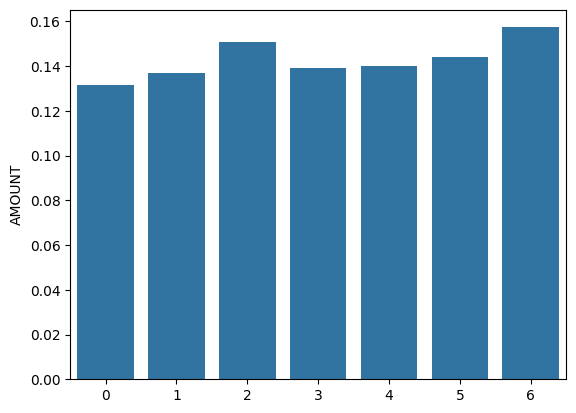

In [75]:
sns.barplot(a['AMOUNT'] / df['AMOUNT'].sum())

In [76]:
sum(a['AMOUNT'] / df['AMOUNT'].sum())

1.0

In [16]:
class ETL:
    """
    Production-ready ETL для фичей цен и временных агрегатов
    """

    # -----------------------------
    # ВСПОМОГАТЕЛЬНЫЕ ПРОВЕРКИ
    # -----------------------------
    @staticmethod
    def _check_columns(df: pd.DataFrame, cols: Iterable[str]) -> None:
        missing = set(cols) - set(df.columns)
        if missing:
            raise KeyError(f"Missing required columns: {missing}")

    # -----------------------------
    # BINNING ЦЕН
    # -----------------------------
    @staticmethod
    def aggregate_price_bins(
        df: pd.DataFrame,
        n_bins: int = 10,
        min_unique_prices: int = 2
    ) -> pd.DataFrame:
        """
        Биннинг UNITPRICE внутри ITEMCODE и агрегация AMOUNT / TOTALPRICE
        """

        ETL._check_columns(
            df,
            ['ITEMCODE', 'DATE_', 'UNITPRICE', 'AMOUNT', 'TOTALPRICE', 'BASEPRICE', 'cost']
        )

        def _bin_item(group: pd.DataFrame) -> pd.DataFrame:
            if group['UNITPRICE'].nunique() < min_unique_prices:
                return group

            prices = group['UNITPRICE']

            bins = np.linspace(prices.min(), prices.max(), n_bins + 1)
            labels = (bins[:-1] + bins[1:]) / 2

            group = group.copy()
            group['UNITPRICE'] = pd.cut(
                prices,
                bins=bins,
                labels=labels,
                include_lowest=True
            ).astype(float)

            return group

        df = (
            df
            .groupby('ITEMCODE', group_keys=False)
            .apply(_bin_item)
        )

        group_cols = ['ITEMCODE', 'DATE_', 'UNITPRICE']
        other_cols = [c for c in ['CATEGORY1', 'CATEGORY2', 'ITEMID', 'BASEPRICE', 'cost'] if c in df.columns]

        return (
            df
            .groupby(group_cols + other_cols, as_index=False)
            .agg({
                'AMOUNT': 'sum',
                'TOTALPRICE': 'sum'
            })
        )

    # -----------------------------
    # ROLLING-ФИЧИ
    # -----------------------------
    @staticmethod
    def window_features(df: pd.DataFrame) -> pd.DataFrame:
        ETL._check_columns(df, ['ITEMCODE', 'DATE_', 'UNITPRICE', 'TOTALPRICE', 'BASEPRICE', 'cost', 'AMOUNT'])
       
        agg_dict = {
            'UNITPRICE': 'mean',
            'AMOUNT': 'sum',
            'TOTALPRICE': 'sum',
            'BASEPRICE': 'first',
            'cost': 'first',
        }
       
        # категории (если есть)
        for c in ['CATEGORY1', 'CATEGORY2']:
            if c in df.columns:
                agg_dict[c] = 'first'
       
        df = (
            df
            .groupby(['ITEMCODE', 'DATE_'], as_index=False)
            .agg(agg_dict)
            .sort_values(['ITEMCODE', 'DATE_'])
            .reset_index(drop=True)
        )
    
        df['discount'] = 1 - (df['UNITPRICE'] / df['BASEPRICE'])
        df['margin_%'] = (df['UNITPRICE'] - df['cost']) / df['cost']
       
        # -----------------------------
        # ROLLING
        # -----------------------------
        def _rolling(col, func, window, group_col, future=False):
            rolled = (
                df
                .set_index('DATE_')
                .groupby(group_col)[col]
                .apply(
                    lambda x: x.rolling(window=window, min_periods=1).agg(func)
                )
            )
       
            shift_val = int(''.join(filter(str.isdigit, window)))
            rolled = rolled.groupby(level=0).shift(-shift_val if future else 1)
       
           
            return rolled.reset_index(level=0, drop=True).to_numpy()
       
        # UNITPRICE stats
        for stat in ['min', 'mean', 'max']:
            df[f'UNITPRICE_{stat}_last_30days'] = _rolling(
                'UNITPRICE', stat, '30D', 'ITEMCODE'
            )
           
       
        # SUM metrics
        for days in [1, 7, 15, 30]:
            window = f'{days}D'
       
            df[f'AMOUNT_{days}D'] = _rolling(
                'AMOUNT', 'sum', window, 'ITEMCODE'
            )
       
            df[f'TOTALPRICE_{days}D'] = _rolling(
                'TOTALPRICE', 'sum', window, 'ITEMCODE'
            )
       
            df[f'GMV_{days}D'] = _rolling(
                'TOTALPRICE', 'sum', window, 'ITEMCODE', future=True
            )
       
        # обрезка краёв
        min_date = df['DATE_'].min() + pd.Timedelta('30D')
        max_date = df['DATE_'].max() - pd.Timedelta('30D')
       
        return df[(df['DATE_'] >= min_date) & (df['DATE_'] <= max_date)]

    # -----------------------------
    # ВРЕМЕННЫЕ ФИЧИ
    # -----------------------------
    @staticmethod
    def time_features(df: pd.DataFrame) -> pd.DataFrame:
        ETL._check_columns(df, ['DATE_'])

        df = df.copy()

        df['dow_sin'] = np.sin(df['DATE_'].dt.weekday)
        df['dom_sin'] = np.sin(df['DATE_'].dt.day)
        df['doy_sin'] = np.sin(df['DATE_'].dt.dayofyear)
        df['month_sin'] = np.sin(df['DATE_'].dt.month)
        df['year_sin'] = np.sin(df['DATE_'].dt.year)

        return df

    # -----------------------------
    # FEATURE SELECTION
    # -----------------------------
    @staticmethod
    def feature_selection(df: pd.DataFrame) -> pd.DataFrame:
        drop_cols = {
            'ORDERID',
            'ORDERDETAILID',
            'AMOUNT',
            'DATE_',
            'TOTALPRICE',
            'ITEMID'
        }

        return df.drop(columns=list(drop_cols & set(df.columns)))


In [11]:
df

,Unnamed: 0,ORDERID,ORDERDETAILID,AMOUNT,UNITPRICE,TOTALPRICE,ITEMID,ITEMCODE,DATE_,CATEGORY1,CATEGORY2,cost,BASEPRICE
434425,434425,98682,494757,3,24.07,72.21,50,107,2021-11-21,Home,Electric-Electronic,27.31,34.4
434437,434437,1701580,8505513,1,30.25,30.25,50,107,2022-01-21,Home,Electric-Electronic,27.31,34.4
434439,434439,285262,1429661,3,19.68,59.04,50,107,2021-02-26,Home,Electric-Electronic,27.31,34.4
434441,434441,334392,1675555,3,38.67,116.01,50,107,2022-11-25,Home,Electric-Electronic,27.31,34.4
434449,434449,1050891,5255556,7,31.43,220.01,50,107,2022-02-10,Home,Electric-Electronic,27.31,34.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50400380,50400380,69630,348765,5,36.68,183.40,50,107,2022-08-05,Home,Electric-Electronic,27.31,34.4
50400398,50400398,2154047,10769539,1,21.19,21.19,50,107,2021-04-14,Home,Electric-Electronic,27.31,34.4
50400412,50400412,831112,4157191,3,25.58,76.74,50,107,2021-12-01,Home,Electric-Electronic,27.31,34.4
50439526,50439526,4286007,21432248,6,22.52,135.12,50,107,2021-08-03,Home,Electric-Electronic,27.31,34.4


In [17]:
df = ETL.aggregate_price_bins(df)
df = ETL.window_features(df)
df = ETL.time_features(df)
df = ETL.feature_selection(df)


/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_86703/2715536676.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_bin_item)


In [18]:
import numpy as np
import pandas as pd


class PriceCandidates:
    """
    Generates candidate price grid for each row in dataset.

    For every observation creates N candidate prices using multiplicative
    deviations from original UNITPRICE.

    Parameters
    ----------
    n_candidates : int
        Number of candidate prices per observation.
    scope : float
        Upper bound of price deviation.
        Price factors will be generated in range:
            [1 - 0.5, 1 + scope]
    """

    REQUIRED_COLUMNS = {"UNITPRICE"}

    def __init__(self, n_candidates: int = 100, scope: float = 0.5):
        self.n_candidates = n_candidates
        self.scope = scope

    # ---------------------------------------------------------
    # Public API
    # ---------------------------------------------------------
    def generate(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Create candidate price grid.

        Parameters
        ----------
        df : pd.DataFrame
            Input dataset.

        Returns
        -------
        pd.DataFrame
            Expanded dataframe with candidate prices.
        """

        self._validate_input(df)

        base_df = self._prepare_base_df(df)
        factors_df = self._build_price_factors()

        grid_df = self._cross_join(base_df, factors_df)
        grid_df = self._apply_price_transform(grid_df)

        refrash_feature = self.refrash_feature(grid_df)

        return refrash_feature

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------
    def _validate_input(self, df: pd.DataFrame) -> None:
        missing = self.REQUIRED_COLUMNS - set(df.columns)

        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        if not pd.api.types.is_numeric_dtype(df["UNITPRICE"]):
            raise TypeError("UNITPRICE must be numeric")

    # ---------------------------------------------------------
    # Base preparation
    # ---------------------------------------------------------
    def _prepare_base_df(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Copy dataframe and create stable row identifier.
        """

        base_df = df.copy()
        base_df["Id"] = np.arange(len(base_df))

        return base_df

    # ---------------------------------------------------------
    # Candidate factors
    # ---------------------------------------------------------
    def _build_price_factors(self) -> pd.DataFrame:
        """
        Create multiplicative price deviation grid.
        """

        deviations = np.linspace(
            -0.5,
            self.scope,
            self.n_candidates
        )

        return pd.DataFrame({
            "price_factor": 1 + deviations,
            "price_idx": np.arange(self.n_candidates)
        })

    def refrash_feature(self, df):
        
        df['discount'] = 1 - (df['UNITPRICE'] / df['BASEPRICE'])
        df['margin_%'] = (df['UNITPRICE'] - df['cost']) / df['cost']
        

        return df
    
    # ---------------------------------------------------------
    # Join logic
    # ---------------------------------------------------------
    def _cross_join(
        self,
        base_df: pd.DataFrame,
        factors_df: pd.DataFrame
    ) -> pd.DataFrame:

        # safer & faster than merge(..., how="cross") in many cases
        base_df["_tmp"] = 1
        factors_df["_tmp"] = 1

        grid_df = base_df.merge(factors_df, on="_tmp").drop("_tmp", axis=1)

        base_df.drop("_tmp", axis=1, inplace=True)
        factors_df.drop("_tmp", axis=1, inplace=True)

        return grid_df

    # ---------------------------------------------------------
    # Price transform
    # ---------------------------------------------------------
    def _apply_price_transform(self, grid_df: pd.DataFrame) -> pd.DataFrame:
        grid_df["UNITPRICE"] = (
            grid_df["UNITPRICE"].median() * grid_df["price_factor"]
        )

        grid_df["n_sku"] = (
            "price_" + grid_df["price_idx"].astype(str)
        )

        return grid_df.drop(columns=["price_factor", "price_idx"])


## Модель эластичности

In [19]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import Pipeline
from scipy.interpolate import PchipInterpolator
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt

In [38]:
batch_df = df[df.ITEMCODE == 107]

In [20]:
batch_df.columns

Index(['ITEMCODE', 'UNITPRICE', 'BASEPRICE', 'cost', 'CATEGORY1', 'CATEGORY2',
       'discount', 'margin_%', 'UNITPRICE_min_last_30days',
       'UNITPRICE_mean_last_30days', 'UNITPRICE_max_last_30days', 'AMOUNT_7D',
       'TOTALPRICE_7D', 'GMV_7D', 'AMOUNT_15D', 'TOTALPRICE_15D', 'GMV_15D',
       'AMOUNT_30D', 'TOTALPRICE_30D', 'GMV_30D', 'dow_sin', 'dom_sin',
       'doy_sin', 'month_sin', 'year_sin'],
      dtype='object')

In [39]:
target = batch_df['GMV_7D']
train = batch_df.drop(['CATEGORY1', 'CATEGORY2','GMV_1D', 'GMV_7D', 'GMV_15D', 'AMOUNT_7D','AMOUNT_15D', 'AMOUNT_30D', 'GMV_30D', 'cost'], axis=1)

In [40]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from scipy.interpolate import PchipInterpolator

class Elasticity:
    def __init__(self, df, target):
        self.df = df
        self.target = target
        self.pipeline = None
        self.model = None
        self.columns = None
        self.random_state = 42

    def _prepare_data(self, data):
        """Внутренний метод для очистки данных перед подачей в пайплайн"""
        drop_cols = ['ITEMCODE', 'Id', 'n_sku']
        return data.drop(columns=[col for col in drop_cols if col in data.columns], axis=1)

    def fit(self):
        self.target = self.target.fillna(0)
        
        # 1. Подготавливаем признаки (удаляем лишние колонки)
        train_df = self._prepare_data(self.df)
        self.columns = train_df.columns
        
        # 2. Создаем пайплайн: Полиномы -> Масштабирование -> Модель
        # include_bias=False, чтобы не добавлять колонку из единиц (Lasso сам справится с intercept)
        self.pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', LassoCV(
                cv=5, 
                n_alphas=100,         # Верните 100 для более точного поиска
                max_iter=1000,       # Увеличиваем лимит итераций, чтобы ушла ошибка
                tol=0.01,             # Немного ослабляем допуск для ускорения
                random_state=self.random_state,
                selection='random'    # 'random' часто быстрее сходится на больших данных
            ))
        ])
        
        # 3. Обучаем пайплайн
        self.pipeline.fit(train_df, self.target)
        
        # Для совместимости сохраняем ссылку на саму модель Lasso
        self.model = self.pipeline.named_steps['model']
        
    def predict(self, data):
        # 1. Оставляем только те колонки, на которых учились
        data_clean = data[self.columns]
        
        # 2. Делаем предсказание через весь пайплайн (он сам применит poly и scaler)
        # Это критически важно, так как модель Lasso теперь ждет на вход расширенный набор признаков
        pred = self.pipeline.predict(data_clean)

        pred = np.clip(pred, 0, np.inf)
        
        data['pred_GMV'] = pred
        return data

    def modify_elasticity(self, data, min_diff=1.0, tail_zero_price_mult=1.5):
        """Метод остается без изменений, так как он работает с пост-обработкой спроса"""
        def process_group(group):
            if len(group) < 2: return group
            group = group.sort_values('UNITPRICE')
            prices = group['UNITPRICE'].values
            qtys = group['qlt'].values
            
            suffix_max = np.maximum.accumulate(qtys[::-1])[::-1]
            mono_mask = (qtys >= suffix_max)
            p_mono, q_mono = prices[mono_mask], qtys[mono_mask]
            
            final_px, final_qy = [p_mono[0]], [q_mono[0]]
            for i in range(1, len(q_mono)):
                if abs(final_qy[-1] - q_mono[i]) >= min_diff:
                    final_px.append(p_mono[i])
                    final_qy.append(q_mono[i])
            
            zero_price = final_px[-1] * tail_zero_price_mult
            final_px.append(zero_price)
            final_qy.append(0.0)
            
            if len(final_px) >= 2:
                try:
                    interp_func = PchipInterpolator(final_px, final_qy)
                    group['qlt'] = interp_func(prices)
                except: pass
            return group

        return data.groupby('Id', group_keys=False).apply(process_group).sort_index()

    def get_model(self):
        return self.model

In [100]:
train

,ITEMCODE,UNITPRICE,BASEPRICE,discount,margin_%,UNITPRICE_min_last_30days,UNITPRICE_mean_last_30days,UNITPRICE_max_last_30days,TOTALPRICE_7D,TOTALPRICE_15D,TOTALPRICE_30D,dow_sin,dom_sin,doy_sin,month_sin,year_sin
28,107,16.2625,34.4,0.527253,-0.404522,16.2625,17.555750,21.4355,1230.65,2234.86,4862.00,0.000000,0.841471,0.551427,0.909297,-0.816847
29,107,16.2625,34.4,0.527253,-0.404522,16.2625,17.371000,21.4355,1046.53,2328.82,4933.94,0.841471,0.909297,0.999912,0.909297,-0.816847
30,107,16.2625,34.4,0.527253,-0.404522,16.2625,17.371000,21.4355,1238.59,2344.92,5130.80,0.909297,0.141120,0.529083,0.909297,-0.816847
31,107,16.2625,34.4,0.527253,-0.404522,16.2625,17.186250,21.4355,1318.17,2334.42,5170.28,0.141120,-0.756802,-0.428183,0.909297,-0.816847
32,107,16.2625,34.4,0.527253,-0.404522,16.2625,17.186250,21.4355,1338.85,2315.99,5047.90,-0.756802,-0.958924,-0.991779,0.909297,-0.816847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782,107,21.4355,34.4,0.376875,-0.215104,5.9165,36.622897,42.1275,1538.80,4152.43,9172.46,0.000000,-0.544021,0.594909,0.656987,-0.184604
783,107,34.3680,34.4,0.000930,0.258440,5.9165,35.988873,42.1275,872.92,3310.03,8409.88,0.841471,-0.999990,-0.354938,0.656987,-0.184604
784,107,5.9165,34.4,0.828009,-0.783358,5.9165,35.926532,42.1275,1031.81,3250.30,8576.77,0.909297,-0.536573,-0.978457,0.656987,-0.184604
785,107,11.0895,34.4,0.677631,-0.593940,5.9165,34.533801,42.1275,576.85,3119.86,8440.53,0.141120,0.420167,-0.702386,0.656987,-0.184604


In [37]:
import numpy as np
from catboost import CatBoostRegressor, Pool


class ElasticityCatBoost:
    def __init__(self, df, target, cat_features=None):
        self.df = df
        self.target = target
        self.cat_features = cat_features if cat_features is not None else []

        self.model = None
        self.columns = None
        self.random_state = 42

    def _prepare_data(self, data):
        drop_cols = ['ITEMCODE', 'Id', 'n_sku']
        return data.drop(columns=[c for c in drop_cols if c in data.columns], axis=1)

    def fit(self):
        self.target = self.target.fillna(0)
    
        train_df = self._prepare_data(self.df)
        self.columns = train_df.columns
    
        # индексы категориальных
        cat_idx = [train_df.columns.get_loc(c) for c in self.cat_features if c in train_df.columns]
    
        # -------------------------
        # МОНОТОННОСТЬ
        # -------------------------
        monotone = []
        for col in train_df.columns:
            if col == 'UNITPRICE':
                monotone.append(-1)  # цена растет → спрос падает
            else:
                monotone.append(0)
    
        train_pool = Pool(
            data=train_df,
            label=self.target,
            cat_features=cat_idx
        )
    
        self.model = CatBoostRegressor(
            iterations=100,
            depth=6,
            learning_rate=0.03,
            loss_function='RMSE',
            eval_metric='RMSE',
            monotone_constraints=monotone,
            random_seed=self.random_state,
            verbose=200,
            early_stopping_rounds=200
        )
    
        self.model.fit(train_pool)

    def predict(self, data):
        data_clean = data[self.columns]

        cat_idx = [data_clean.columns.get_loc(c) for c in self.cat_features if c in data_clean.columns]

        pool = Pool(
            data=data_clean,
            cat_features=cat_idx
        )

        pred = self.model.predict(pool)
        pred = np.clip(pred, 0, np.inf)

        data['pred_GMV'] = pred
        return data

    def modify_elasticity(self, data, min_diff=1.0, tail_zero_price_mult=1.5):
        from scipy.interpolate import PchipInterpolator

        def process_group(group):
            if len(group) < 2:
                return group

            group = group.sort_values('UNITPRICE')
            prices = group['UNITPRICE'].values
            qtys = group['qlt'].values

            suffix_max = np.maximum.accumulate(qtys[::-1])[::-1]
            mono_mask = (qtys >= suffix_max)
            p_mono, q_mono = prices[mono_mask], qtys[mono_mask]

            final_px, final_qy = [p_mono[0]], [q_mono[0]]
            for i in range(1, len(q_mono)):
                if abs(final_qy[-1] - q_mono[i]) >= min_diff:
                    final_px.append(p_mono[i])
                    final_qy.append(q_mono[i])

            zero_price = final_px[-1] * tail_zero_price_mult
            final_px.append(zero_price)
            final_qy.append(0.0)

            if len(final_px) >= 2:
                try:
                    interp_func = PchipInterpolator(final_px, final_qy)
                    group['qlt'] = interp_func(prices)
                except:
                    pass

            return group

        return data.groupby('Id', group_keys=False).apply(process_group).sort_index()

    def get_model(self):
        return self.model


In [41]:

model = Elasticity(
    df=train,
    target=target
)

model.fit()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.826e+06, tolerance: 3.344e+06
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: Conv

In [39]:

model = ElasticityCatBoost(
    df=train,
    target=target
)

model.fit()


0:	learn: 27.5528970	total: 59.3ms	remaining: 5.87s
99:	learn: 6.4309419	total: 204ms	remaining: 0us


In [42]:
price_generator = PriceCandidates(
    n_candidates=1000,
    scope=1.5
)
grid_df = price_generator.generate(df[df.ITEMCODE == 107])


In [36]:
df.columns

Index(['ITEMCODE', 'UNITPRICE', 'BASEPRICE', 'cost', 'CATEGORY1', 'CATEGORY2',
       'discount', 'margin_%', 'UNITPRICE_min_last_30days',
       'UNITPRICE_mean_last_30days', 'UNITPRICE_max_last_30days', 'AMOUNT_7D',
       'TOTALPRICE_7D', 'GMV_7D', 'AMOUNT_15D', 'TOTALPRICE_15D', 'GMV_15D',
       'AMOUNT_30D', 'TOTALPRICE_30D', 'GMV_30D', 'dow_sin', 'dom_sin',
       'doy_sin', 'month_sin', 'year_sin'],
      dtype='object')

In [92]:
a = df['UNITPRICE'].value_counts().reset_index().rename(columns={"index": "price", 0: "count"})
a = a.sort_values(by='UNITPRICE')
a

,UNITPRICE,count
6,5.916500,2
10,11.089500,1
4,16.262500,19
8,17.986833,1
1,21.435500,188
3,26.608500,85
7,31.781500,1
2,31.781500,148
9,34.368000,1
0,36.954500,296


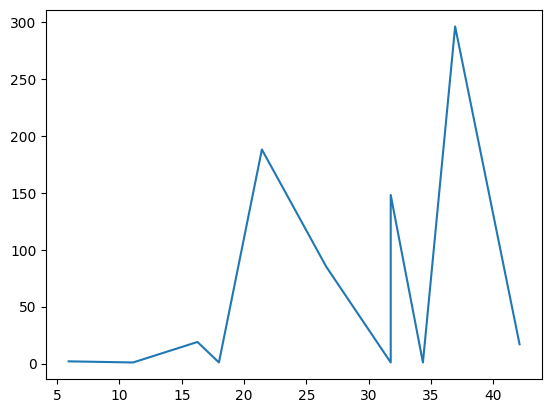

In [93]:
plt.plot(a['UNITPRICE'], a['count'])

In [94]:
model = Pipeline([
            ('poly', PolynomialFeatures(degree=1, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', LassoCV(
                cv=5, 
                n_alphas=100,         # Верните 100 для более точного поиска
                max_iter=1000,       # Увеличиваем лимит итераций, чтобы ушла ошибка
                tol=0.01,             # Немного ослабляем допуск для ускорения
                random_state=312,
                selection='random'    # 'random' часто быстрее сходится на больших данных
            ))
        ])
        
        # 3. Обучаем пайплайн
model.fit(a['UNITPRICE'].values.reshape(-1, 1), a['count'])



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [45]:
grid_df['pred_GMV'] = grid_df['pred_GMV'] / 7

In [43]:
pred = model.predict(grid_df)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [44]:
pred

,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,UNITPRICE_min_last_30days,UNITPRICE_mean_last_30days,...,TOTALPRICE_30D,GMV_30D,dow_sin,dom_sin,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV
0,107,15.890750,34.4,27.31,Home,Electric-Electronic,0.538060,-0.418134,16.2625,17.555750,...,4862.0,6577.12,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_0,1265.126058
1,107,15.954377,34.4,27.31,Home,Electric-Electronic,0.536210,-0.415805,16.2625,17.555750,...,4862.0,6577.12,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_1,1266.626239
2,107,16.018003,34.4,27.31,Home,Electric-Electronic,0.534360,-0.413475,16.2625,17.555750,...,4862.0,6577.12,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_2,1268.123781
3,107,16.081630,34.4,27.31,Home,Electric-Electronic,0.532511,-0.411145,16.2625,17.555750,...,4862.0,6577.12,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_3,1269.618685
4,107,16.145257,34.4,27.31,Home,Electric-Electronic,0.530661,-0.408815,16.2625,17.555750,...,4862.0,6577.12,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_4,1271.110951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758995,107,79.199243,34.4,27.31,Home,Electric-Electronic,-1.302304,1.900009,5.9165,33.538994,...,7976.1,NaN,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_995,609.779460
758996,107,79.262870,34.4,27.31,Home,Electric-Electronic,-1.304153,1.902339,5.9165,33.538994,...,7976.1,NaN,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_996,608.102947
758997,107,79.326497,34.4,27.31,Home,Electric-Electronic,-1.306003,1.904669,5.9165,33.538994,...,7976.1,NaN,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_997,606.423796
758998,107,79.390123,34.4,27.31,Home,Electric-Electronic,-1.307852,1.906998,5.9165,33.538994,...,7976.1,NaN,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_998,604.742007


In [27]:
model.get_model().coef_

array([  0.        ,   0.        ,  -0.        ,   0.        ,
        15.50263111,   0.        ,   0.        ,  -0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        -0.        ,   0.        ,   0.        ,  -0.        ,
        -0.        ,   0.        ,   0.        ,  -0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        -0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  -0.        ,   0.        ,   0.        ,
        -0.        ,  -0.        ,   0.        ,  -0.        ,
         0.        ,  11.09318177,   0.        ,   0.        ,
        -0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  -0.        ,   0.        ,   0.        ,
        -0.        ,  -0.        ,  -0.        ,   0.        ,
        -0.        ,  -0.        ,  -0.        ,  -0.        ,
        -0.        ,  -0.        ,  -0.        ,  -0.        ,
        -0.        ,   0.        ,  -0.        ,  -0.  

In [46]:
pred['qlt'] = pred['pred_GMV'] / pred['UNITPRICE']
pred['margin_P'] = pred['pred_GMV'] - pred['cost'] * pred['qlt']

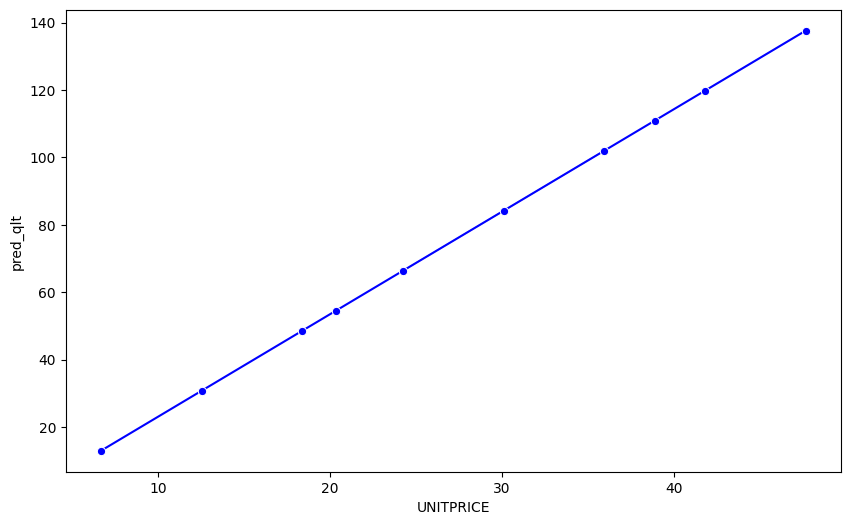

In [99]:

fig, ax1 = plt.subplots(figsize=(10, 6))

# Построить данные по основной оси Y
sns.lineplot(x=pred[pred['n_sku'] == 'price_12']['UNITPRICE'], y=pred[pred['n_sku'] == 'price_12']['pred_qlt'], ax=ax1, color="blue", marker="o")

# # Создать вспомогательную ось Y
# ax2 = ax1.twinx()

# # Построить данные по вспомогательной оси Y
# sns.lineplot(x=pred[pred['n_sku'] == 'price_12']['UNITPRICE'], y=pred[pred['n_sku'] == 'price_12']['margin_%'], ax=ax2, color="green", marker="s")

plt.show()


In [147]:
pred

,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,UNITPRICE_min_last_30days,UNITPRICE_mean_last_30days,...,dow_sin,dom_sin,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV,qlt,margin_P
0,107,8.131250,34.4,27.31,Home,Electric-Electronic,0.763626,-0.702261,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_0,1065.294080,131.012339,-2512.652894
1,107,8.295518,34.4,27.31,Home,Electric-Electronic,0.758851,-0.696246,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_1,1069.720002,128.951567,-2451.947288
2,107,8.459785,34.4,27.31,Home,Electric-Electronic,0.754076,-0.690231,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_2,1074.128588,126.968776,-2393.388674
3,107,8.624053,34.4,27.31,Home,Electric-Electronic,0.749301,-0.684216,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_3,1078.519839,125.059509,-2336.855357
4,107,8.788321,34.4,27.31,Home,Electric-Electronic,0.744526,-0.678201,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_4,1082.893755,123.219645,-2282.234743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75895,107,53.938639,34.4,27.31,Home,Electric-Electronic,-0.567984,0.975051,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_95,1063.830978,19.722985,525.196251
75896,107,54.311917,34.4,27.31,Home,Electric-Electronic,-0.578835,0.988719,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_96,1059.954502,19.516058,526.970965
75897,107,54.685194,34.4,27.31,Home,Electric-Electronic,-0.589686,1.002387,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_97,1055.988511,19.310318,528.623718
75898,107,55.058472,34.4,27.31,Home,Electric-Electronic,-0.600537,1.016055,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_98,1051.933007,19.105743,530.155172


<Axes: xlabel='UNITPRICE', ylabel='qlt'>

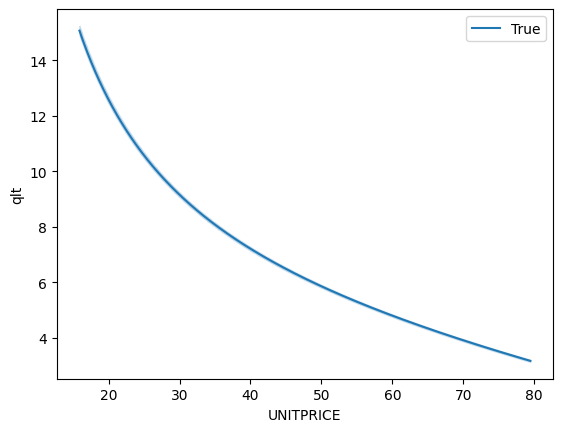

In [47]:
sns.lineplot(x=pred['UNITPRICE'], y=pred['qlt'], hue=True)

In [30]:
pred

,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,UNITPRICE_min_last_30days,UNITPRICE_mean_last_30days,...,dow_sin,dom_sin,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV,qlt,margin_P
0,107,8.131250,34.4,27.31,Home,Electric-Electronic,0.763626,-0.702261,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_0,1120.763106,137.834048,-2643.484756
1,107,8.163808,34.4,27.31,Home,Electric-Electronic,0.762680,-0.701069,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_1,1121.609481,137.388035,-2630.457764
2,107,8.196365,34.4,27.31,Home,Electric-Electronic,0.761734,-0.699877,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_2,1122.455001,136.945461,-2617.525544
3,107,8.228923,34.4,27.31,Home,Electric-Electronic,0.760787,-0.698685,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_3,1123.299664,136.506285,-2604.686981
4,107,8.261480,34.4,27.31,Home,Electric-Electronic,0.759841,-0.697492,16.2625,17.555750,...,0.000000,0.841471,0.551427,0.909297,-0.816847,0,price_4,1124.143472,136.070467,-2591.940979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758995,107,92.090318,34.4,27.31,Home,Electric-Electronic,-1.677044,2.372037,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_995,0.000000,0.000000,0.000000
758996,107,92.164301,34.4,27.31,Home,Electric-Electronic,-1.679195,2.374746,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_996,0.000000,0.000000,0.000000
758997,107,92.238284,34.4,27.31,Home,Electric-Electronic,-1.681345,2.377455,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_997,0.000000,0.000000,0.000000
758998,107,92.312267,34.4,27.31,Home,Electric-Electronic,-1.683496,2.380164,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_998,0.000000,0.000000,0.000000


<Axes: xlabel='UNITPRICE', ylabel='pred_GMV'>

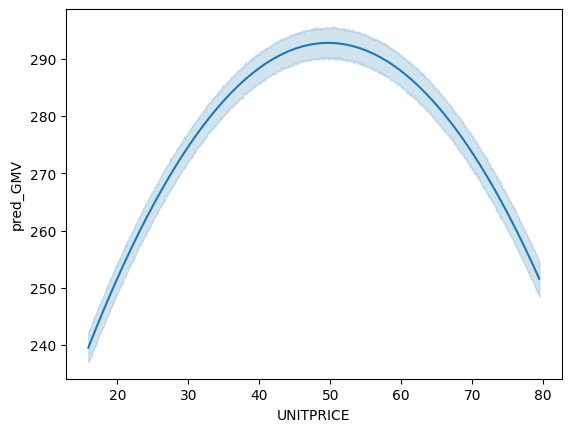

In [48]:
sns.lineplot(x=pred['UNITPRICE'], y=pred['pred_GMV'])

<Axes: xlabel='UNITPRICE', ylabel='pred_GMV'>

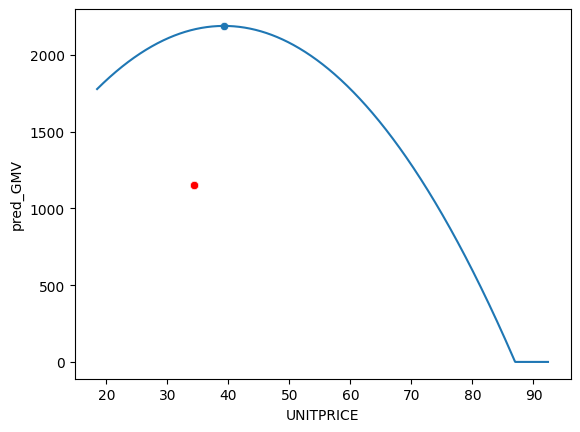

In [137]:
g = pred[pred['Id'] == 500]

sns.lineplot(x=g['UNITPRICE'], y=g['pred_GMV'])
sns.scatterplot(x=g[g['pred_GMV'] == g['pred_GMV'].max()]['UNITPRICE'], y=g['pred_GMV'].max())
sns.scatterplot(x=g['BASEPRICE'], y=1150, c='r')

In [34]:
g

,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,UNITPRICE_min_last_30days,UNITPRICE_mean_last_30days,...,dow_sin,dom_sin,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV,qlt,margin_P
758000,107,18.477250,34.4,27.31,Home,Electric-Electronic,0.462871,-0.323425,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_0,1006.106568,54.451099,-480.952944
758001,107,18.551233,34.4,27.31,Home,Electric-Electronic,0.460720,-0.320716,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_1,1007.226109,54.294295,-475.551077
758002,107,18.625216,34.4,27.31,Home,Electric-Electronic,0.458569,-0.318007,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_2,1008.341064,54.138490,-470.181091
758003,107,18.699199,34.4,27.31,Home,Electric-Electronic,0.456419,-0.315298,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_3,1009.451433,53.983673,-464.842664
758004,107,18.773182,34.4,27.31,Home,Electric-Electronic,0.454268,-0.312589,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_4,1010.557217,53.829831,-459.535477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758995,107,92.090318,34.4,27.31,Home,Electric-Electronic,-1.677044,2.372037,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_995,0.000000,0.000000,0.000000
758996,107,92.164301,34.4,27.31,Home,Electric-Electronic,-1.679195,2.374746,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_996,0.000000,0.000000,0.000000
758997,107,92.238284,34.4,27.31,Home,Electric-Electronic,-1.681345,2.377455,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_997,0.000000,0.000000,0.000000
758998,107,92.312267,34.4,27.31,Home,Electric-Electronic,-1.683496,2.380164,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,758,price_998,0.000000,0.000000,0.000000


In [29]:
pred

,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,UNITPRICE_min_last_30days,UNITPRICE_mean_last_30days,...,dow_sin,dom_sin,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV,qlt,margin_P
0,107,8.131250,34.4,27.31,Home,Electric-Electronic,0.763626,-0.702261,16.2625,17.603648,...,-0.279415,-0.404038,-0.404038,0.841471,-0.816847,0,price_0,506.820947,62.330016,-1195.411804
1,107,8.212971,34.4,27.31,Home,Electric-Electronic,0.761251,-0.699269,16.2625,17.603648,...,-0.279415,-0.404038,-0.404038,0.841471,-0.816847,0,price_1,506.621336,61.685513,-1178.010025
2,107,8.294692,34.4,27.31,Home,Electric-Electronic,0.758875,-0.696276,16.2625,17.603648,...,-0.279415,-0.404038,-0.404038,0.841471,-0.816847,0,price_2,506.621336,61.077774,-1161.412672
3,107,8.376413,34.4,27.31,Home,Electric-Electronic,0.756500,-0.693284,16.2625,17.603648,...,-0.279415,-0.404038,-0.404038,0.841471,-0.816847,0,price_3,506.621336,60.481893,-1145.139169
4,107,8.458134,34.4,27.31,Home,Electric-Electronic,0.754124,-0.690292,16.2625,17.603648,...,-0.279415,-0.404038,-0.404038,0.841471,-0.816847,0,price_4,506.621336,59.897527,-1129.180130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151995,107,54.688946,34.4,27.31,Home,Electric-Electronic,-0.589795,1.002525,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,759,price_195,381.539476,6.976537,191.010240
151996,107,54.874647,34.4,27.31,Home,Electric-Electronic,-0.595193,1.009324,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,759,price_196,381.539476,6.952928,191.655009
151997,107,55.060348,34.4,27.31,Home,Electric-Electronic,-0.600592,1.016124,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,759,price_197,381.539476,6.929478,192.295429
151998,107,55.246049,34.4,27.31,Home,Electric-Electronic,-0.605990,1.022924,5.9165,33.538994,...,-0.756802,0.990607,0.219455,0.656987,-0.184604,759,price_198,381.539476,6.906186,192.931543


In [41]:
pred['margin_%'] = np.clip((pred['UNITPRICE'] - pred['cost']) / pred['UNITPRICE'], 0, 2)

In [31]:
pred['margin_%'] = (pred['UNITPRICE'] - pred['cost']) / pred['UNITPRICE']

In [43]:
pred.to_csv('pred_elastics.csv')

In [23]:
pred['margin_%'] = np.clip((pred['UNITPRICE'] - pred['cost']) / pred['UNITPRICE'], -2, 2)

# Попытка сделать оптимизацию самостоятельно

In [32]:
# сгруппируем и переведем в тензеры

In [32]:
prices = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='UNITPRICE', aggfunc='first')
)

margin = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='margin_P', aggfunc='first')
)

margin_percent = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='margin_%', aggfunc='first')
)

GMV = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='pred_GMV', aggfunc='first')
)


In [33]:
import torch 

In [34]:
prices_t = torch.tensor(prices.values)
GMV_t = torch.tensor(GMV.values)
margin_percent_t = torch.tensor(margin_percent.values)
margin_t = torch.tensor(margin.values)

train_matrix = torch.randn(prices.shape[0], prices.shape[1], requires_grad = True)


In [55]:
# loss = GMV + B * max(margin, 0) -> max

In [35]:
GMV = GMV_t
margin = margin_t
margin_p = margin_percent_t

In [202]:
margin_p

tensor([[-0.4181, -0.4158, -0.4135,  ...,  1.9047,  1.9070,  1.9093],
        [-0.4181, -0.4158, -0.4135,  ...,  1.9047,  1.9070,  1.9093],
        [-0.4181, -0.4158, -0.4135,  ...,  1.9047,  1.9070,  1.9093],
        ...,
        [-0.4181, -0.4158, -0.4135,  ...,  1.9047,  1.9070,  1.9093],
        [-0.4181, -0.4158, -0.4135,  ...,  1.9047,  1.9070,  1.9093],
        [-0.4181, -0.4158, -0.4135,  ...,  1.9047,  1.9070,  1.9093]],
       dtype=torch.float64)

In [36]:

alpha = 10e-4
lambd = 10e-2

target_margin_p = 200
for _ in range(1000):
    # f = -(GMV * train_matrix -  torch.clamp_min(margin * train_matrix, 0))
    f = - (GMV * (1 - lambd * torch.clamp_min(target_margin_p - margin, 0)) * train_matrix) 
    f.backward(gradient=torch.ones_like(f))
    with torch.no_grad():
        train_matrix -= alpha * train_matrix.grad
    
    train_matrix.grad.zero_()
    
    print(f.mean())

tensor(-1.7009, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-16075.2811, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-32148.8612, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-48222.4414, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-64296.0215, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-80369.6016, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-96443.1818, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-112516.7619, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-128590.3420, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-144663.9222, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-160737.5023, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-176811.0824, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-192884.6625, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-208958.2427, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-225031.8228, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor

In [204]:
import numpy as np

<Axes: >

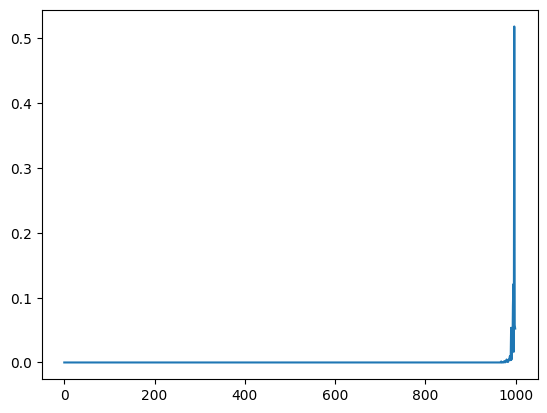

In [37]:
y = torch.softmax(train_matrix, dim=1)[0].detach().numpy()
x = np.arange(len(y))

sns.lineplot(x=x, y=y)

<Axes: >

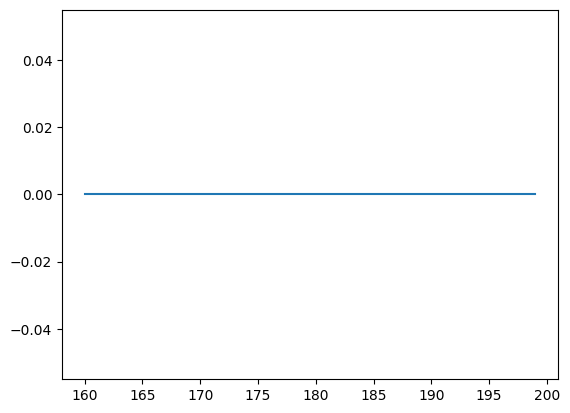

In [31]:
y = torch.softmax(train_matrix, dim=1)[0].detach().numpy()[160:200]
x = np.arange(160, 160 + len(y))

sns.lineplot(x=x, y=y)

In [32]:
best = torch.softmax(1000 * train_matrix, dim=1)[756]
r = torch.argmax(best, dim=0)
# ff = torch.argmax(r, dim=0)

In [143]:
ff

tensor(756)

In [180]:
r = r.detach().numpy()
sns.histplot(r)

TypeError: len() of unsized object

In [181]:
best

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 

In [182]:
y = best
x = np.arange(0,  len(y))

sns.lineplot(x=x, y=y)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [33]:
P = np.max((prices_t[0] * best).detach().numpy())
G = np.max((GMV_t[0] * best).detach().numpy())
M = np.max((margin_t[0] * best).detach().numpy())
M_p = np.max((margin_percent_t[0] * best).detach().numpy())
print(P, G, M, G/P, M_p)

38.47820245245245 1588.7250644959975 461.12349410038496 41.28896266552957 0.2902475100351429


In [126]:
margin_t

tensor([[-2643.4848, -2630.4578, -2617.5255,  ...,   502.2757,   503.0966,
           503.9159],
        [-2696.3554, -2682.8956, -2669.5346,  ...,   502.3290,   503.1539,
           503.9773],
        [-2623.7708, -2610.9020, -2598.1265,  ...,   501.7696,   502.5878,
           503.4043],
        ...,
        [-4596.6378, -4579.5050, -4562.5038,  ...,  -765.8144,  -764.7071,
          -763.6010],
        [-2838.0761, -2826.2299, -2814.4714,  ...,    14.8143,    15.6946,
            16.5738],
        [ -480.9529,  -475.5511,  -470.1811,  ...,     0.0000,     0.0000,
             0.0000]], dtype=torch.float64)

In [1]:
import pandas as pd

In [107]:
pred = pd.read_csv('../pred_elastics.csv')

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
batch_size = 1  # количество Id (портфелей)
n_prices = 1000  # количество опций цен на каждый Id

ids = np.repeat(np.arange(batch_size), n_prices)
price_idxs = np.tile(np.arange(n_prices), batch_size)
n_skus = [f'price_{idx}' for idx in price_idxs]

# Pivot tables
prices = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='UNITPRICE', aggfunc='first')
)

margin = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='margin_P', aggfunc='first')
)

margin_percent = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='margin_%', aggfunc='first')
)

GMV = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='pred_GMV', aggfunc='first')
)

# Сортировка индексов
prices = prices.sort_index()
margin = margin.sort_index()
margin_percent = margin_percent.sort_index()
GMV = GMV.sort_index()

# Класс ConstraintBuilder
class ConstraintBuilder:
    def __init__(self, gmv, margin, prices, margin_percent):
        self.gmv = gmv
        self.margin = margin
        self.prices = prices
        self.margin_percent = margin_percent
        self.n_items, self.n_prices = gmv.shape
        self.mask = np.ones_like(gmv, dtype=float)
    
    def build(self):
        return self.mask

builder = ConstraintBuilder(GMV.values, margin.values, prices.values, margin_percent.values, cost=None)
valid_mask = (
    builder
    .build()
)



# Класс PortfolioOptimizer
class PortfolioOptimizer(nn.Module):
    def __init__(self, gmv_m, margin_m, valid_mask, beta=10.0):
        super().__init__()
        self.gmv = torch.tensor(gmv_m, dtype=torch.float32)
        self.margin = torch.tensor(margin_m, dtype=torch.float32)
        self.valid_mask = torch.tensor(valid_mask, dtype=torch.float32)
        self.beta = beta
        self.logits = nn.Parameter(torch.zeros(self.gmv.shape))
    
    def _masked_logits(self):
        return self.logits * self.valid_mask + (1 - self.valid_mask) * -1e9
    
    def get_prob_matrix(self):
        with torch.no_grad():
            probs = torch.softmax(self._masked_logits() * self.beta, dim=1)
        return probs.cpu().numpy()
    
    def get_best_indices(self):
        with torch.no_grad():
            idx = torch.argmax(self._masked_logits(), dim=1)
        return idx.cpu().numpy()
    
    def forward(self):
        mask = torch.softmax(self._masked_logits() * self.beta, dim=1)
        item_gmv = (self.gmv * mask).sum(dim=1)
        item_margin = (self.margin * mask).sum(dim=1)
        return item_gmv, item_margin
    
    def compute_scores(self, gmv_min):
        if not isinstance(gmv_min, torch.Tensor):
            gmv_min = torch.tensor(gmv_min, dtype=torch.float32)
        penalties = self.beta * torch.max(torch.zeros_like(self.gmv), gmv_min.unsqueeze(1) - self.gmv)
        scores = self.margin - penalties
        return scores
    
    def get_greedy_indices(self, gmv_min):
        scores = self.compute_scores(gmv_min)
        with torch.no_grad():
            idx = torch.argmax(masked_scores, dim=1)
        return idx.cpu().numpy()

# Функция для запуска обучения
def train_portfolio_optimizer(
    gmv_matrix,          
    margin_matrix,       
    valid_mask_matrix,   
    gmv_min_values,      
    beta=10.0,
    lr=0.05,
    n_epochs=300,
    temperature=10.0,    
    temperature_decay=0.995,
    print_every=50,
    device='cpu'         
):
    batch_size, n_items = gmv_matrix.shape
    
    gmv = torch.tensor(gmv_matrix, dtype=torch.float32, device=device)
    margin = torch.tensor(margin_matrix, dtype=torch.float32, device=device)
    valid_mask = torch.tensor(valid_mask_matrix, dtype=torch.float32, device=device)
    
    if gmv_min_values is None:
        gmv_min = torch.zeros((batch_size,), device=device)
    else:
        gmv_min = torch.tensor(gmv_min_values, dtype=torch.float32, device=device)
    
    model = PortfolioOptimizer(
        gmv_m=gmv,
        margin_m=margin,
        valid_mask=valid_mask,
        beta=temperature
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print(f"Запуск обучения: batch={batch_size}, items={n_items}, epochs={n_epochs}, device={device}")
    print(f"Начальная температура (beta): {temperature:.2f}")
    
    best_margin = -float('inf')
    best_epoch = 0
    
    for epoch in range(n_epochs):
        #optimizer.zero_grad()
        
        item_gmv, item_margin = gmv_matrix,  margin_matrix
        
        underfill = torch.relu(gmv_min - item_gmv)
        penalty = beta * underfill
        
        objective = item_margin.sum() * item_gmv.sum() - penalty.sum()
        loss = -objective
        
        loss.backward()
        #optimizer.step()
        
        model.beta *= temperature_decay
        current_beta = model.beta
        
        if (epoch + 1) % print_every == 0 or epoch == 0 or epoch == n_epochs - 1:
            avg_gmv = item_gmv.mean().item()
            avg_margin = item_margin.mean().item()
            avg_penalty = penalty.mean().item()
            coverage = (item_gmv >= gmv_min).float().mean().item() * 100
            
            print(f"[{epoch+1:4d}/{n_epochs}] "
                  f"loss: {loss.item():.2f} | "
                  f"margin: {avg_margin:8.2f} | "
                  f"GMV: {avg_gmv:8.2f} | "
                  f"penalty: {avg_penalty:6.2f} | "
                  f"coverage: {coverage:5.1f}% | "
                  f"β: {current_beta:.3f}")
            
            if avg_margin > best_margin:
                best_margin = avg_margin
                best_epoch = epoch + 1
    
    print(f"\nОбучение завершено. Лучшая средняя маржа: {best_margin:.2f} на эпохе {best_epoch}")
    
    with torch.no_grad():
        probs = model.get_prob_matrix()
        best_indices = model.get_best_indices()
        greedy_indices = model.get_greedy_indices(gmv_min)
        
        final_gmv, final_margin = model()
        final_underfill = torch.relu(gmv_min - final_gmv)
    
    print("\nЖадный выбор по logits:")
    print(best_indices)
    
    print("\nЖадный выбор по Score (политика II):")
    print(greedy_indices)
    
    print(f"\nФинальная средняя маржа: {final_margin.mean().item():.2f}")
    print(f"Финальное покрытие GMV_min: {(final_gmv >= gmv_min).float().mean().item()*100:.1f}%")
    
    return model, {
        'final_gmv': final_gmv.cpu().numpy(),
        'final_margin': final_margin.cpu().numpy(),
        'best_indices': best_indices,
        'greedy_indices_policy_II': greedy_indices,
        'probs': probs
    }

if __name__ == "__main__":
    # Генерация gmv_min
    gmv_min_values = np.zeros(batch_size)
    
    model, results = train_portfolio_optimizer(
        gmv_matrix=GMV.values,
        margin_matrix=margin.values,
        valid_mask_matrix=valid_mask,
        gmv_min_values=None,
        beta=15.0,
        lr=0.03,
        n_epochs=500,
        temperature=7.0,
        temperature_decay=0.992,
        print_every=50
    )
    
    best_price_indices = model.get_best_indices()
    prob_matrix = model.get_prob_matrix()
    
    ids = prices.index.to_numpy()
    chosen_prices = prices.to_numpy()[
        np.arange(len(best_price_indices)),
        best_price_indices
    ]
    
    # ============= КРАСИВЫЙ ВЫВОД В PANDAS DF =============
    
    # 1. Основной результат с выбранными ценами
    result = pd.DataFrame({
        'Id': ids,
        'UNITPRICE_opt': chosen_prices,
        'selected_price_idx': best_price_indices,
        'GMV_opt': results['final_gmv'],
        'margin_P_opt': results['final_margin']
    })
    
    
    
    # 2. Детальный анализ с исходными данными
    pred = pred.copy()
    pred['price_idx'] = (
        pred['n_sku']
        .str.replace('price_', '', regex=False)
        .astype(int)
    )
    
    grid = pred.copy()
    grid['price_idx'] = grid['n_sku'].str.replace('price_', '').astype(int)
    
    final_choice = pd.DataFrame({
        'Id': ids,
        'price_idx': best_price_indices
    })
    
    # Слияние с полной информацией
    result_merge = final_choice.merge(
        grid,
        how='left',
        on=['Id', 'price_idx']
    )
    
    # 3. Сводная статистика по портфелю
    portfolio_summary = pd.DataFrame({
        'Метрика': [
            'Количество ID',
            'Количество опций цен',
            'Средняя выбранная цена',
            'Суммарный GMV',
            'Средняя маржа (P)',
            'Средняя маржа (%)',
            'GMV целевой (min)',
            'Покрытие GMV',
            'Температура (β)',
            'Learning rate'
        ],
        'Значение': [
            f'{len(result):,}',
            f'{n_prices:,}',
            f'{result["UNITPRICE_opt"].mean():,.2f} ₽',
            f'{result["GMV_opt"].sum():,.2f} ₽',
            f'{result["margin_P_opt"].mean():,.2f} ₽',
            f'{result_merge["margin_%"].mean():.2%}',
            f'{gmv_min_values[0]:,.2f} ₽',
            f'{(result["GMV_opt"].iloc[0] >= gmv_min_values[0])*100:.1f}%',
            '12.0 → {:.3f}'.format(model.beta),
            '0.03'
        ]
    })

    print(portfolio_summary)
    
    # styled_summary = portfolio_summary.style.set_properties(**{
    #     'border': '1px solid #D5D8DC',
    #     'font-size': '11pt',
    #     'font-family': 'Arial'
    # }).set_table_styles([
    #     {'selector': 'th',
    #      'props': [('background-color', '#5D6D7E'),
    #                ('color', 'white'),
    #                ('font-weight', 'bold')]},
    #     {'selector': 'td',
    #      'props': [('padding', '8px')]},
    #     {'selector': 'tr:nth-child(even)',
    #      'props': [('background-color', '#F2F4F4')]}
    # ]).set_caption("📈 СВОДНАЯ СТАТИСТИКА ПОРТФЕЛЯ")
    

    # 5. Анализ распределения вероятностей
    prob_df = pd.DataFrame(
        prob_matrix.T,
        columns=[f'ID_{i}' for i in range(prob_matrix.shape[0])],
        index=[f'price_{i}' for i in range(prob_matrix.shape[1])]
    )
    
    top_probs = prob_df.nlargest(10, prob_df.columns[0]) if prob_matrix.shape[0] > 0 else prob_df.head(10)
    

    
    # 7. Простой текстовый вывод для консоли
    print("\n" + "="*60)
    print("📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ")
    print("="*60)
    print(result.to_string(index=False))
    
    print("\n" + "="*60)
    print("📈 СВОДНАЯ СТАТИСТИКА")
    print("="*60)
    for _, row in portfolio_summary.iterrows():
        print(f"{row['Метрика']:<30} {row['Значение']:>25}")
    
    print("\n" + "="*60)
    print("🏆 ТОП-3 ЛУЧШИХ ОПЦИИ")
    print("="*60)
    print(top_options.head(3).to_string(index=False))
    
    # # 8. Сохранение результатов в CSV (опционально)
    # # result.to_csv('optimized_prices.csv', index=False)
    # # result_merge.to_csv('optimized_prices_full.csv', index=False)
    
    # 9. Проверка на соответствие ограничениям
    constraint_check = pd.DataFrame({
        'Id': ids,
        'GMV_opt': results['final_gmv'],
        'GMV_min': gmv_min_values,
        'Выполнено': results['final_gmv'] >= gmv_min_values,
        'Отклонение': results['final_gmv'] - gmv_min_values,
        'Маржа_opt': results['final_margin']
    })
    
    styled_check = constraint_check.style.format({
        'GMV_opt': '{:,.2f} ₽',
        'GMV_min': '{:,.2f} ₽',
        'Отклонение': '{:,.2f} ₽',
        'Маржа_opt': '{:,.2f} ₽'
    }).applymap(
        lambda x: 'color: green; font-weight: bold' if x else 'color: red; font-weight: bold',
        subset=['Выполнено']
    ).set_caption("✅ ПРОВЕРКА ВЫПОЛНЕНИЯ ОГРАНИЧЕНИЙ")
    
    try:
        display(styled_check)
    except:
        print("\n" + "="*60)
        print("✅ ПРОВЕРКА ОГРАНИЧЕНИЙ")
        print("="*60)
        print(constraint_check.to_string(index=False))
    
    # Вывод результатов для проверки
    print("\n" + "="*60)
    print("📋 ДЕТАЛИ ВЫБОРКИ")
    print("="*60)
    print("\nresult head:")
    print(result.head())
    
    print("\nresult_merge head:")
    print(result_merge.head())
    
    print("\ns head:")
    s = pred.merge(
        final_choice[['Id', 'price_idx']],
        left_on=['Id', 'price_idx'],
        right_on=['Id', 'price_idx'],
        how='inner'
    )
    print(s.head())

/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_57435/640734458.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gmv = torch.tensor(gmv_m, dtype=torch.float32)
/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_57435/640734458.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.margin = torch.tensor(margin_m, dtype=torch.float32)
/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_57435/640734458.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.valid_mask = torch.tensor(valid_mask, dtype=t

Запуск обучения: batch=759, items=1000, epochs=500, device=cpu
Начальная температура (beta): 7.00
[   1/500] loss: -553030909952.00 | margin:   589.46 | GMV:  1628.59 | penalty:   0.00 | coverage: 100.0% | β: 6.944
[  50/500] loss: -929551548416.00 | margin:   871.33 | GMV:  1851.86 | penalty:   0.00 | coverage: 100.0% | β: 4.685
[ 100/500] loss: -933335072768.00 | margin:   875.02 | GMV:  1851.56 | penalty:   0.00 | coverage: 100.0% | β: 3.135
[ 150/500] loss: -932749115392.00 | margin:   874.95 | GMV:  1850.53 | penalty:   0.00 | coverage: 100.0% | β: 2.098
[ 200/500] loss: -930511585280.00 | margin:   873.41 | GMV:  1849.36 | penalty:   0.00 | coverage: 100.0% | β: 1.404
[ 250/500] loss: -922811891712.00 | margin:   867.99 | GMV:  1845.50 | penalty:   0.00 | coverage: 100.0% | β: 0.940
[ 300/500] loss: -899602382848.00 | margin:   851.64 | GMV:  1833.63 | penalty:   0.00 | coverage: 100.0% | β: 0.629
[ 350/500] loss: -840885796864.00 | margin:   809.62 | GMV:  1802.91 | penalty:   0

ValueError: All arrays must be of the same length

In [48]:
s

NameError: name 's' is not defined

In [151]:
s['offset'] = (s['BASEPRICE'] - s['UNITPRICE']) / s['BASEPRICE'] 

In [138]:
import seaborn as sns

<Axes: xlabel='UNITPRICE', ylabel='Count'>

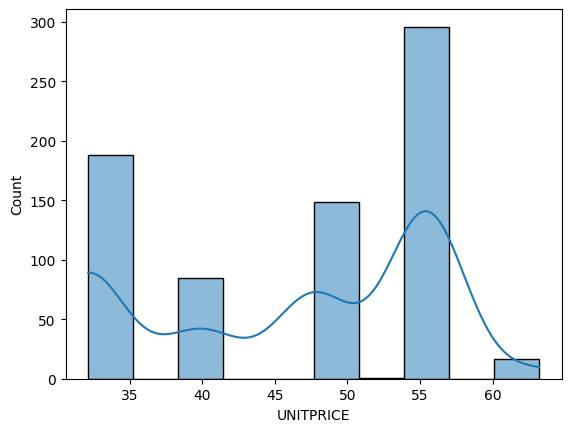

In [152]:
sns.histplot(s[s['UNITPRICE'] >= s['cost']]['UNITPRICE'], kde=True, bins=10)

<Axes: xlabel='margin_%', ylabel='Count'>

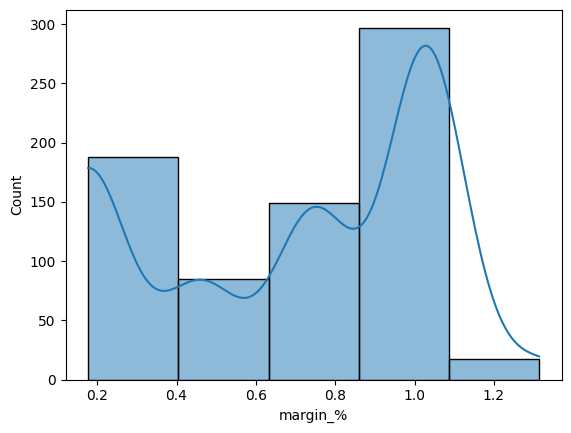

In [153]:
sns.histplot(s[s['UNITPRICE'] >= s['cost']]['margin_%'], bins=5, kde=True)

In [39]:
valid_mask

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.]])

In [55]:
pred['Id'].nunique()

760

In [63]:
r = pred[pred['Id'] == 0]

In [64]:
r

,Unnamed: 0.1,Unnamed: 0,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,...,dom_sin,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV,qlt,margin_P,price_idx
0,0,0,107,8.131250,34.4,27.31,Home,Electric-Electronic,0.763626,-2.358647,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_0,506.820947,62.330016,-1195.411804,0
1,1,1,107,8.212971,34.4,27.31,Home,Electric-Electronic,0.761251,-2.325228,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_1,506.621336,61.685513,-1178.010025,1
2,2,2,107,8.294692,34.4,27.31,Home,Electric-Electronic,0.758875,-2.292467,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_2,506.621336,61.077774,-1161.412672,2
3,3,3,107,8.376413,34.4,27.31,Home,Electric-Electronic,0.756500,-2.260345,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_3,506.621336,60.481893,-1145.139169,3
4,4,4,107,8.458134,34.4,27.31,Home,Electric-Electronic,0.754124,-2.228844,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_4,506.621336,59.897527,-1129.180130,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,195,107,24.066866,34.4,27.31,Home,Electric-Electronic,0.300382,-0.134755,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_195,496.545993,20.631934,-66.912137,195
196,196,196,107,24.148587,34.4,27.31,Home,Electric-Electronic,0.298006,-0.130915,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_196,496.545993,20.562114,-65.005341,196
197,197,197,107,24.230308,34.4,27.31,Home,Electric-Electronic,0.295631,-0.127101,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_197,496.545993,20.492765,-63.111407,197
198,198,198,107,24.312029,34.4,27.31,Home,Electric-Electronic,0.293255,-0.123312,...,-0.404038,-0.404038,0.841471,-0.816847,0,price_198,496.545993,20.423881,-61.230206,198


In [68]:
r['loss'] = r['pred_GMV'] * r['margin_P'] - np.maximum(0, np.min(r['pred_GMV']) - r['pred_GMV'])

/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_61577/1968765588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['loss'] = r['pred_GMV'] * r['margin_P'] - np.maximum(0, np.min(r['pred_GMV']) - r['pred_GMV'])


In [69]:
r

,Unnamed: 0.1,Unnamed: 0,ITEMCODE,UNITPRICE,BASEPRICE,cost,CATEGORY1,CATEGORY2,discount,margin_%,...,doy_sin,month_sin,year_sin,Id,n_sku,pred_GMV,qlt,margin_P,price_idx,loss
0,0,0,107,8.131250,34.4,27.31,Home,Electric-Electronic,0.763626,-2.358647,...,-0.404038,0.841471,-0.816847,0,price_0,506.820947,62.330016,-1195.411804,0,-605859.741743
1,1,1,107,8.212971,34.4,27.31,Home,Electric-Electronic,0.761251,-2.325228,...,-0.404038,0.841471,-0.816847,0,price_1,506.621336,61.685513,-1178.010025,1,-596805.012884
2,2,2,107,8.294692,34.4,27.31,Home,Electric-Electronic,0.758875,-2.292467,...,-0.404038,0.841471,-0.816847,0,price_2,506.621336,61.077774,-1161.412672,2,-588396.439572
3,3,3,107,8.376413,34.4,27.31,Home,Electric-Electronic,0.756500,-2.260345,...,-0.404038,0.841471,-0.816847,0,price_3,506.621336,60.481893,-1145.139169,3,-580151.935983
4,4,4,107,8.458134,34.4,27.31,Home,Electric-Electronic,0.754124,-2.228844,...,-0.404038,0.841471,-0.816847,0,price_4,506.621336,59.897527,-1129.180130,4,-572066.746473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,195,107,24.066866,34.4,27.31,Home,Electric-Electronic,0.300382,-0.134755,...,-0.404038,0.841471,-0.816847,0,price_195,496.545993,20.631934,-66.912137,195,-33224.953418
196,196,196,107,24.148587,34.4,27.31,Home,Electric-Electronic,0.298006,-0.130915,...,-0.404038,0.841471,-0.816847,0,price_196,496.545993,20.562114,-65.005341,196,-32278.141653
197,197,197,107,24.230308,34.4,27.31,Home,Electric-Electronic,0.295631,-0.127101,...,-0.404038,0.841471,-0.816847,0,price_197,496.545993,20.492765,-63.111407,197,-31337.716476
198,198,198,107,24.312029,34.4,27.31,Home,Electric-Electronic,0.293255,-0.123312,...,-0.404038,0.841471,-0.816847,0,price_198,496.545993,20.423881,-61.230206,198,-30403.613486


In [51]:
np.random.seed(42)
batch_size = 1  # количество Id (портфелей)
n_prices = 1000  # количество опций цен на каждый Id

ids = np.repeat(np.arange(batch_size), n_prices)
price_idxs = np.tile(np.arange(n_prices), batch_size)
n_skus = [f'price_{idx}' for idx in price_idxs]

# Pivot tables
prices = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='UNITPRICE', aggfunc='first')
)

margin = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='margin_P', aggfunc='first')
)

margin_percent = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='margin_%', aggfunc='first')
)

GMV = (
    pred.assign(idx=pred.groupby('Id').cumcount())
    .pivot_table(index='Id', columns='idx', values='pred_GMV', aggfunc='first')
)

# Сортировка индексов
prices = prices.sort_index()
margin = margin.sort_index()
margin_percent = margin_percent.sort_index()
GMV = GMV.sort_index()